Create our first log dataset

In [10]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.20.101-hotspot"

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("DistributedLogProcessing")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)
print("Spark is ready!")

C:\Python311\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark version: 4.2.0
Spark is ready!


In [11]:
import csv
import random
from datetime import datetime, timedelta

urls = ["/", "/home", "/login", "/products", "/cart", "/checkout"]
methods = ["GET", "POST"]
status_codes = [200, 200, 200, 201, 404, 500]

start_time = datetime(2026, 1, 1, 10, 0, 0)

with open("logs_10k.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)

    writer.writerow([
        "timestamp",
        "method",
        "url",
        "status",
        "response_size"
    ])

    for i in range(10000):
        timestamp = start_time + timedelta(seconds=i)

        writer.writerow([
            timestamp,
            random.choice(methods),
            random.choice(urls),
            random.choice(status_codes),
            random.randint(100, 5000)
        ])

print("10,000 log records created successfully!")



10,000 log records created successfully!


Process the logs using Sequential Python

In [12]:
import csv
import time
from collections import Counter

start_time = time.perf_counter()

total_requests = 0
status_counts = Counter()
url_counts = Counter()
client_errors = 0
server_errors = 0

with open("logs_10k.csv", "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for row in reader:
        total_requests += 1

        status = int(row["status"])
        url = row["url"]

        status_counts[status] += 1
        url_counts[url] += 1

        if 400 <= status < 500:
            client_errors += 1

        elif 500 <= status < 600:
            server_errors += 1

end_time = time.perf_counter()

execution_time = end_time - start_time
throughput = total_requests / execution_time

print("----- SEQUENTIAL PYTHON -----")
print("Total Requests:", total_requests)
print("Status Counts:", status_counts)
print("4xx Errors:", client_errors)
print("5xx Errors:", server_errors)
print("URL Counts:", url_counts)

print("\nExecution Time:", round(execution_time, 4), "seconds")
print("Throughput:", round(throughput, 2), "records/second")

----- SEQUENTIAL PYTHON -----
Total Requests: 10000
Status Counts: Counter({200: 5032, 500: 1673, 404: 1654, 201: 1641})
4xx Errors: 1654
5xx Errors: 1673
URL Counts: Counter({'/cart': 1683, '/checkout': 1677, '/': 1673, '/login': 1670, '/home': 1649, '/products': 1648})

Execution Time: 0.083 seconds
Throughput: 120500.37 records/second


Spark processing

In [13]:
import time
from pyspark.sql.functions import col

start_time = time.perf_counter()

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("logs_10k.csv")
)

total_requests_spark = df.count()

status_counts_spark = (
    df.groupBy("status")
    .count()
    .orderBy("status")
    .collect()
)

client_errors_spark = df.filter(
    (col("status") >= 400) & (col("status") < 500)
).count()

server_errors_spark = df.filter(
    (col("status") >= 500) & (col("status") < 600)
).count()

url_counts_spark = (
    df.groupBy("url")
    .count()
    .orderBy(col("count").desc())
    .collect()
)

end_time = time.perf_counter()

spark_execution_time = end_time - start_time
spark_throughput = total_requests_spark / spark_execution_time

print("----- APACHE SPARK -----")
print("Total Requests:", total_requests_spark)

print("\nStatus Counts:")
for row in status_counts_spark:
    print(row["status"], row["count"])

print("\n4xx Errors:", client_errors_spark)
print("5xx Errors:", server_errors_spark)

print("\nURL Counts:")
for row in url_counts_spark:
    print(row["url"], row["count"])

print("\nExecution Time:",
      round(spark_execution_time, 4), "seconds")

print("Throughput:",
      round(spark_throughput, 2), "records/second")

----- APACHE SPARK -----
Total Requests: 10000

Status Counts:
200 5032
201 1641
404 1654
500 1673

4xx Errors: 1654
5xx Errors: 1673

URL Counts:
/cart 1683
/checkout 1677
/ 1673
/login 1670
/home 1649
/products 1648

Execution Time: 14.8238 seconds
Throughput: 674.59 records/second


In [14]:
import csv
import random
from datetime import datetime, timedelta

urls = ["/", "/home", "/login", "/products", "/cart", "/checkout"]
methods = ["GET", "POST"]
status_codes = [200, 200, 200, 201, 404, 500]

def generate_logs(number_of_records, file_name):

    start_time = datetime(2026, 1, 1, 10, 0, 0)

    with open(file_name, "w", newline="", encoding="utf-8") as file:

        writer = csv.writer(file)

        writer.writerow([
            "timestamp",
            "method",
            "url",
            "status",
            "response_size"
        ])

        for i in range(number_of_records):

            timestamp = start_time + timedelta(seconds=i)

            writer.writerow([
                timestamp,
                random.choice(methods),
                random.choice(urls),
                random.choice(status_codes),
                random.randint(100, 5000)
            ])

    print(f"{number_of_records:,} log records created successfully!")

In [15]:
generate_logs(100000, "logs_100k.csv")

100,000 log records created successfully!


In [16]:
import csv
import time
from collections import Counter

def run_sequential(file_name):

    start_time = time.perf_counter()

    total_requests = 0
    status_counts = Counter()
    url_counts = Counter()
    client_errors = 0
    server_errors = 0

    with open(file_name, "r", encoding="utf-8") as file:

        reader = csv.DictReader(file)

        for row in reader:

            total_requests += 1

            status = int(row["status"])
            url = row["url"]

            status_counts[status] += 1
            url_counts[url] += 1

            if 400 <= status < 500:
                client_errors += 1

            elif 500 <= status < 600:
                server_errors += 1

    execution_time = time.perf_counter() - start_time
    throughput = total_requests / execution_time

    print("----- SEQUENTIAL PYTHON -----")
    print("Total Requests:", total_requests)
    print("Status Counts:", status_counts)
    print("4xx Errors:", client_errors)
    print("5xx Errors:", server_errors)
    print("URL Counts:", url_counts)
    print("Execution Time:", round(execution_time, 4), "seconds")
    print("Throughput:", round(throughput, 2), "records/second")

    return execution_time, throughput

In [17]:
python_time_100k, python_throughput_100k = run_sequential("logs_100k.csv")

----- SEQUENTIAL PYTHON -----
Total Requests: 100000
Status Counts: Counter({200: 49886, 201: 16936, 404: 16677, 500: 16501})
4xx Errors: 16677
5xx Errors: 16501
URL Counts: Counter({'/home': 16840, '/': 16741, '/login': 16676, '/checkout': 16595, '/cart': 16580, '/products': 16568})
Execution Time: 0.596 seconds
Throughput: 167796.05 records/second


In [18]:
import time
from pyspark.sql.functions import col

def run_spark(file_name):

    start_time = time.perf_counter()

    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv(file_name)
    )

    total_requests = df.count()

    status_counts = (
        df.groupBy("status")
        .count()
        .orderBy("status")
        .collect()
    )

    client_errors = df.filter(
        (col("status") >= 400) & (col("status") < 500)
    ).count()

    server_errors = df.filter(
        (col("status") >= 500) & (col("status") < 600)
    ).count()

    url_counts = (
        df.groupBy("url")
        .count()
        .orderBy(col("count").desc())
        .collect()
    )

    execution_time = time.perf_counter() - start_time
    throughput = total_requests / execution_time

    print("----- APACHE SPARK -----")
    print("Total Requests:", total_requests)

    print("\nStatus Counts:")
    for row in status_counts:
        print(row["status"], row["count"])

    print("\n4xx Errors:", client_errors)
    print("5xx Errors:", server_errors)

    print("\nURL Counts:")
    for row in url_counts:
        print(row["url"], row["count"])

    print("\nExecution Time:", round(execution_time, 4), "seconds")
    print("Throughput:", round(throughput, 2), "records/second")

    return execution_time, throughput

In [19]:
spark_time_100k, spark_throughput_100k = run_spark("logs_100k.csv")

----- APACHE SPARK -----
Total Requests: 100000

Status Counts:
200 49886
201 16936
404 16677
500 16501

4xx Errors: 16677
5xx Errors: 16501

URL Counts:
/home 16840
/ 16741
/login 16676
/checkout 16595
/cart 16580
/products 16568

Execution Time: 4.4121 seconds
Throughput: 22664.96 records/second


In [20]:
generate_logs(500000, "logs_500k.csv")

500,000 log records created successfully!


In [21]:
python_time_500k, python_throughput_500k = run_sequential("logs_500k.csv")

----- SEQUENTIAL PYTHON -----
Total Requests: 500000
Status Counts: Counter({200: 250138, 500: 83393, 201: 83377, 404: 83092})
4xx Errors: 83092
5xx Errors: 83393
URL Counts: Counter({'/': 83525, '/products': 83431, '/login': 83389, '/checkout': 83294, '/home': 83189, '/cart': 83172})
Execution Time: 4.0909 seconds
Throughput: 122222.71 records/second


In [22]:
spark_time_500k, spark_throughput_500k = run_spark("logs_500k.csv")

----- APACHE SPARK -----
Total Requests: 500000

Status Counts:
200 250138
201 83377
404 83092
500 83393

4xx Errors: 83092
5xx Errors: 83393

URL Counts:
/ 83525
/products 83431
/login 83389
/checkout 83294
/home 83189
/cart 83172

Execution Time: 9.0333 seconds
Throughput: 55350.53 records/second


In [23]:
generate_logs(1000000, "logs_1m.csv")

1,000,000 log records created successfully!


In [24]:
python_time_1m, python_throughput_1m = run_sequential("logs_1m.csv")

----- SEQUENTIAL PYTHON -----
Total Requests: 1000000
Status Counts: Counter({200: 499882, 500: 166791, 201: 166742, 404: 166585})
4xx Errors: 166585
5xx Errors: 166791
URL Counts: Counter({'/checkout': 167131, '/products': 166952, '/cart': 166846, '/': 166678, '/home': 166206, '/login': 166187})
Execution Time: 8.2402 seconds
Throughput: 121356.13 records/second


In [25]:
spark_time_1m, spark_throughput_1m = run_spark("logs_1m.csv")

----- APACHE SPARK -----
Total Requests: 1000000

Status Counts:
200 499882
201 166742
404 166585
500 166791

4xx Errors: 166585
5xx Errors: 166791

URL Counts:
/checkout 167131
/products 166952
/cart 166846
/ 166678
/home 166206
/login 166187

Execution Time: 13.8813 seconds
Throughput: 72039.15 records/second


In [26]:
generate_logs(5000000, "logs_5m.csv")

5,000,000 log records created successfully!


In [27]:
python_time_5m, python_throughput_5m = run_sequential("logs_5m.csv")

----- SEQUENTIAL PYTHON -----
Total Requests: 5000000
Status Counts: Counter({200: 2499782, 404: 833922, 500: 833763, 201: 832533})
4xx Errors: 833922
5xx Errors: 833763
URL Counts: Counter({'/cart': 834684, '/login': 834003, '/': 833419, '/home': 833076, '/products': 832592, '/checkout': 832226})
Execution Time: 42.5726 seconds
Throughput: 117446.41 records/second


In [28]:
spark_time_5m, spark_throughput_5m = run_spark("logs_5m.csv")

----- APACHE SPARK -----
Total Requests: 5000000

Status Counts:
200 2499782
201 832533
404 833922
500 833763

4xx Errors: 833922
5xx Errors: 833763

URL Counts:
/cart 834684
/login 834003
/ 833419
/home 833076
/products 832592
/checkout 832226

Execution Time: 51.1965 seconds
Throughput: 97662.86 records/second


In [29]:
import csv
import time
from collections import Counter

def experiment_sequential(file_name):

    start_time = time.perf_counter()

    total_requests = 0
    status_counts = Counter()
    url_counts = Counter()
    client_errors = 0
    server_errors = 0

    with open(file_name, "r", encoding="utf-8") as file:

        reader = csv.DictReader(file)

        for row in reader:

            total_requests += 1

            status = int(row["status"])
            url = row["url"]

            status_counts[status] += 1
            url_counts[url] += 1

            if 400 <= status < 500:
                client_errors += 1

            elif 500 <= status < 600:
                server_errors += 1

    execution_time = time.perf_counter() - start_time

    throughput = total_requests / execution_time

    return execution_time, throughput

In [30]:
time_10k, throughput_10k = experiment_sequential("logs_10k.csv")

print("Execution Time:", round(time_10k, 4), "seconds")
print("Throughput:", round(throughput_10k, 2), "records/second")

Execution Time: 0.0469 seconds
Throughput: 213223.25 records/second


In [31]:
import time
from pyspark.sql.functions import col

def experiment_spark(file_name):

    start_time = time.perf_counter()

    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv(file_name)
    )

    total_requests = df.count()

    status_counts = (
        df.groupBy("status")
        .count()
        .collect()
    )

    client_errors = df.filter(
        (col("status") >= 400) & (col("status") < 500)
    ).count()

    server_errors = df.filter(
        (col("status") >= 500) & (col("status") < 600)
    ).count()

    url_counts = (
        df.groupBy("url")
        .count()
        .collect()
    )

    execution_time = time.perf_counter() - start_time

    throughput = total_requests / execution_time

    return execution_time, throughput

In [33]:
spark_time_10k, spark_throughput_10k = experiment_spark("logs_10k.csv")

print("Execution Time:", round(spark_time_10k, 4), "seconds")
print("Throughput:", round(spark_throughput_10k, 2), "records/second")


Execution Time: 1.6336 seconds
Throughput: 6121.28 records/second


In [34]:
python_10k_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_sequential("logs_10k.csv")

    python_10k_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 0.0478 | Throughput: 208998.21
Run: 2 | Time: 0.0475 | Throughput: 210349.62
Run: 3 | Time: 0.0591 | Throughput: 169173.54
Run: 4 | Time: 0.0567 | Throughput: 176387.37
Run: 5 | Time: 0.0687 | Throughput: 145612.34


In [35]:
spark_10k_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_spark("logs_10k.csv")

    spark_10k_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 1.4159 | Throughput: 7062.84
Run: 2 | Time: 1.4235 | Throughput: 7024.76
Run: 3 | Time: 1.3939 | Throughput: 7174.01
Run: 4 | Time: 1.3706 | Throughput: 7295.89
Run: 5 | Time: 1.4189 | Throughput: 7047.5


In [36]:
python_100k_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_sequential("logs_100k.csv")

    python_100k_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 0.4733 | Throughput: 211291.32
Run: 2 | Time: 0.5916 | Throughput: 169030.96
Run: 3 | Time: 0.6355 | Throughput: 157355.6
Run: 4 | Time: 0.6005 | Throughput: 166522.68
Run: 5 | Time: 0.5978 | Throughput: 167271.6


In [37]:
spark_100k_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_spark("logs_100k.csv")

    spark_100k_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 2.8376 | Throughput: 35241.38
Run: 2 | Time: 2.8556 | Throughput: 35018.88
Run: 3 | Time: 2.8356 | Throughput: 35265.66
Run: 4 | Time: 2.8134 | Throughput: 35543.98
Run: 5 | Time: 2.5532 | Throughput: 39165.91


In [38]:
python_500k_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_sequential("logs_500k.csv")

    python_500k_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 2.9415 | Throughput: 169982.6
Run: 2 | Time: 3.1112 | Throughput: 160712.24
Run: 3 | Time: 2.8593 | Throughput: 174868.65
Run: 4 | Time: 3.1244 | Throughput: 160032.14
Run: 5 | Time: 3.162 | Throughput: 158126.98


In [39]:
spark_500k_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_spark("logs_500k.csv")

    spark_500k_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 6.5693 | Throughput: 76111.59
Run: 2 | Time: 6.993 | Throughput: 71500.43
Run: 3 | Time: 6.8461 | Throughput: 73034.09
Run: 4 | Time: 6.8194 | Throughput: 73320.54
Run: 5 | Time: 6.9021 | Throughput: 72441.21


In [40]:
python_1m_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_sequential("logs_1m.csv")

    python_1m_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 6.0242 | Throughput: 165997.8
Run: 2 | Time: 6.2322 | Throughput: 160458.23
Run: 3 | Time: 6.1148 | Throughput: 163538.19
Run: 4 | Time: 6.0493 | Throughput: 165309.39
Run: 5 | Time: 6.2818 | Throughput: 159190.44


In [41]:
spark_1m_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_spark("logs_1m.csv")

    spark_1m_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 11.9107 | Throughput: 83958.1
Run: 2 | Time: 12.2381 | Throughput: 81711.79
Run: 3 | Time: 12.2092 | Throughput: 81905.39
Run: 4 | Time: 12.0368 | Throughput: 83078.4
Run: 5 | Time: 11.7634 | Throughput: 85009.32


In [42]:
python_5m_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_sequential("logs_5m.csv")

    python_5m_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 31.498 | Throughput: 158740.0
Run: 2 | Time: 31.024 | Throughput: 161165.78
Run: 3 | Time: 30.8273 | Throughput: 162193.9
Run: 4 | Time: 30.8667 | Throughput: 161986.72
Run: 5 | Time: 30.8999 | Throughput: 161812.57


In [43]:
spark_5m_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_spark("logs_5m.csv")

    spark_5m_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )
    

Run: 1 | Time: 52.5599 | Throughput: 95129.54
Run: 2 | Time: 51.3172 | Throughput: 97433.19
Run: 3 | Time: 50.4852 | Throughput: 99038.97
Run: 4 | Time: 51.1746 | Throughput: 97704.68
Run: 5 | Time: 50.9151 | Throughput: 98202.66


In [44]:
import statistics

datasets = [
    ("10K", python_10k_results, spark_10k_results),
    ("100K", python_100k_results, spark_100k_results),
    ("500K", python_500k_results, spark_500k_results),
    ("1M", python_1m_results, spark_1m_results),
    ("5M", python_5m_results, spark_5m_results)
]

print(
    f"{'Dataset':<10}"
    f"{'Python Time':<15}"
    f"{'Spark Time':<15}"
    f"{'Python TP':<15}"
    f"{'Spark TP':<15}"
    f"{'Speedup':<10}"
)

for dataset, python_results, spark_results in datasets:

    python_avg_time = statistics.mean(
        result[1] for result in python_results
    )

    spark_avg_time = statistics.mean(
        result[1] for result in spark_results
    )

    python_avg_throughput = statistics.mean(
        result[2] for result in python_results
    )

    spark_avg_throughput = statistics.mean(
        result[2] for result in spark_results
    )

    speedup = python_avg_time / spark_avg_time

    print(
        f"{dataset:<10}"
        f"{python_avg_time:<15.4f}"
        f"{spark_avg_time:<15.4f}"
        f"{python_avg_throughput:<15.2f}"
        f"{spark_avg_throughput:<15.2f}"
        f"{speedup:<10.4f}"
    )

Dataset   Python Time    Spark Time     Python TP      Spark TP       Speedup   
10K       0.0560         1.4046         182104.22      7121.00        0.0399    
100K      0.5797         2.7791         174294.43      36047.16       0.2086    
500K      3.0397         6.8260         164744.52      73281.57       0.4453    
1M        6.1404         12.0317        162898.81      83132.60       0.5104    
5M        31.0232        51.2904        161179.79      97501.81       0.6049    


In [45]:
import os

print("Logical processors:", os.cpu_count())

Logical processors: 8


In [46]:
spark.stop()

In [47]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[1]")
    .appName("DistributedLogProcessing")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark master:", spark.sparkContext.master)
print("Spark version:", spark.version)

Spark master: local[1]
Spark version: 4.2.0


In [48]:
spark_local1_5m_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_spark("logs_5m.csv")

    spark_local1_5m_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )



Run: 1 | Time: 75.3547 | Throughput: 66352.87
Run: 2 | Time: 76.769 | Throughput: 65130.46
Run: 3 | Time: 77.3012 | Throughput: 64682.01
Run: 4 | Time: 77.5571 | Throughput: 64468.63
Run: 5 | Time: 87.1894 | Throughput: 57346.45


In [49]:
spark.stop()

In [50]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[4]")
    .appName("DistributedLogProcessing")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark master:", spark.sparkContext.master)
print("Spark version:", spark.version)

Spark master: local[4]
Spark version: 4.2.0


In [51]:
spark_local4_5m_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_spark("logs_5m.csv")

    spark_local4_5m_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 36.7299 | Throughput: 136128.91
Run: 2 | Time: 32.5633 | Throughput: 153547.26
Run: 3 | Time: 31.1116 | Throughput: 160711.69
Run: 4 | Time: 31.3226 | Throughput: 159629.09
Run: 5 | Time: 33.6808 | Throughput: 148452.61


In [52]:
spark.stop()

In [53]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[8]")
    .appName("DistributedLogProcessing")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark master:", spark.sparkContext.master)
print("Spark version:", spark.version)

Spark master: local[8]
Spark version: 4.2.0


In [54]:
spark_local8_5m_results = []

for run in range(1, 6):

    execution_time, throughput = experiment_spark("logs_5m.csv")

    spark_local8_5m_results.append([
        run,
        execution_time,
        throughput
    ])

    print(
        "Run:", run,
        "| Time:", round(execution_time, 4),
        "| Throughput:", round(throughput, 2)
    )

Run: 1 | Time: 30.7281 | Throughput: 162717.5
Run: 2 | Time: 45.7195 | Throughput: 109362.41
Run: 3 | Time: 72.6024 | Throughput: 68868.25
Run: 4 | Time: 73.7891 | Throughput: 67760.67
Run: 5 | Time: 74.322 | Throughput: 67274.83


In [55]:
import statistics

parallel_results = [
    ("local[1]", spark_local1_5m_results),
    ("local[2]", spark_5m_results),
    ("local[4]", spark_local4_5m_results),
    ("local[8]", spark_local8_5m_results)
]

print(
    f"{'Configuration':<15}"
    f"{'Mean Time':<15}"
    f"{'Std Dev':<15}"
    f"{'Mean Throughput':<20}"
)

for config, results in parallel_results:

    times = [r[1] for r in results]
    throughputs = [r[2] for r in results]

    mean_time = statistics.mean(times)
    std_time = statistics.stdev(times)
    mean_throughput = statistics.mean(throughputs)

    print(
        f"{config:<15}"
        f"{mean_time:<15.4f}"
        f"{std_time:<15.4f}"
        f"{mean_throughput:<20.2f}"
    )

Configuration  Mean Time      Std Dev        Mean Throughput     
local[1]       78.8343        4.7477         63596.08            
local[2]       51.2904        0.7770         97501.81            
local[4]       33.0816        2.2865         151693.91           
local[8]       59.4322        20.0826        95196.73            


In [56]:
import csv

all_results = []

# Experiment 1: Dataset-size comparison
dataset_results = [
    ("10K", 10000, python_10k_results, spark_10k_results),
    ("100K", 100000, python_100k_results, spark_100k_results),
    ("500K", 500000, python_500k_results, spark_500k_results),
    ("1M", 1000000, python_1m_results, spark_1m_results),
    ("5M", 5000000, python_5m_results, spark_5m_results)
]

for dataset, records, python_results, spark_results in dataset_results:

    for run, execution_time, throughput in python_results:
        all_results.append([
            "Dataset Scaling",
            dataset,
            records,
            "Sequential Python",
            1,
            run,
            execution_time,
            throughput
        ])

    for run, execution_time, throughput in spark_results:
        all_results.append([
            "Dataset Scaling",
            dataset,
            records,
            "Spark",
            2,
            run,
            execution_time,
            throughput
        ])


# Experiment 2: Spark parallelism
parallelism_results = [
    (1, spark_local1_5m_results),
    (2, spark_5m_results),
    (4, spark_local4_5m_results),
    (8, spark_local8_5m_results)
]

for threads, results in parallelism_results:

    for run, execution_time, throughput in results:
        all_results.append([
            "Parallelism",
            "5M",
            5000000,
            "Spark",
            threads,
            run,
            execution_time,
            throughput
        ])


with open("experiment_results.csv", "w", newline="") as file:

    writer = csv.writer(file)

    writer.writerow([
        "Experiment",
        "Dataset",
        "Records",
        "Method",
        "Parallelism",
        "Run",
        "Execution_Time",
        "Throughput"
    ])

    writer.writerows(all_results)


print("Results saved successfully!")
print("Total rows saved:", len(all_results))

Results saved successfully!
Total rows saved: 70


In [57]:
import pandas as pd

df_results = pd.read_csv("experiment_results.csv")

print(df_results.head(10))
print("\nTotal rows:", len(df_results))

        Experiment Dataset  Records             Method  Parallelism  Run  \
0  Dataset Scaling     10K    10000  Sequential Python            1    1   
1  Dataset Scaling     10K    10000  Sequential Python            1    2   
2  Dataset Scaling     10K    10000  Sequential Python            1    3   
3  Dataset Scaling     10K    10000  Sequential Python            1    4   
4  Dataset Scaling     10K    10000  Sequential Python            1    5   
5  Dataset Scaling     10K    10000              Spark            2    1   
6  Dataset Scaling     10K    10000              Spark            2    2   
7  Dataset Scaling     10K    10000              Spark            2    3   
8  Dataset Scaling     10K    10000              Spark            2    4   
9  Dataset Scaling     10K    10000              Spark            2    5   

   Execution_Time     Throughput  
0        0.047847  208998.208900  
1        0.047540  210349.622112  
2        0.059111  169173.536497  
3        0.056693  1763

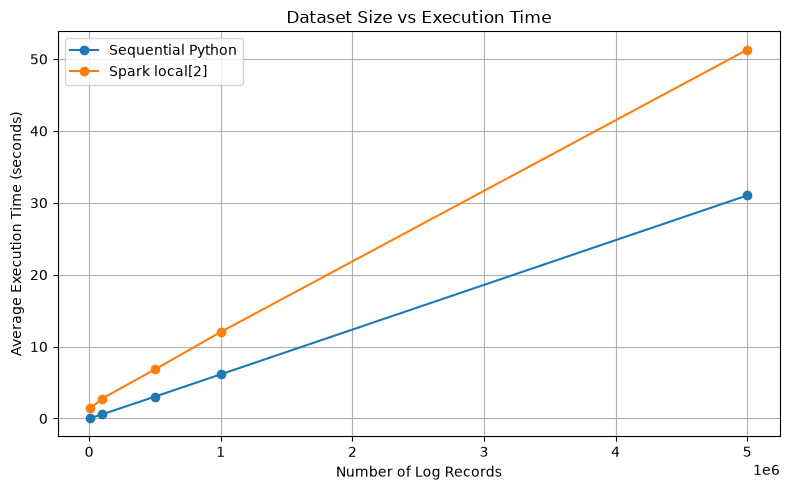

In [58]:
import matplotlib.pyplot as plt

scaling_df = df_results[
    df_results["Experiment"] == "Dataset Scaling"
]

avg_time = (
    scaling_df
    .groupby(["Records", "Method"])["Execution_Time"]
    .mean()
    .reset_index()
)

python_data = avg_time[
    avg_time["Method"] == "Sequential Python"
]

spark_data = avg_time[
    avg_time["Method"] == "Spark"
]

plt.figure(figsize=(8, 5))

plt.plot(
    python_data["Records"],
    python_data["Execution_Time"],
    marker="o",
    label="Sequential Python"
)

plt.plot(
    spark_data["Records"],
    spark_data["Execution_Time"],
    marker="o",
    label="Spark local[2]"
)

plt.xlabel("Number of Log Records")
plt.ylabel("Average Execution Time (seconds)")
plt.title("Dataset Size vs Execution Time")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

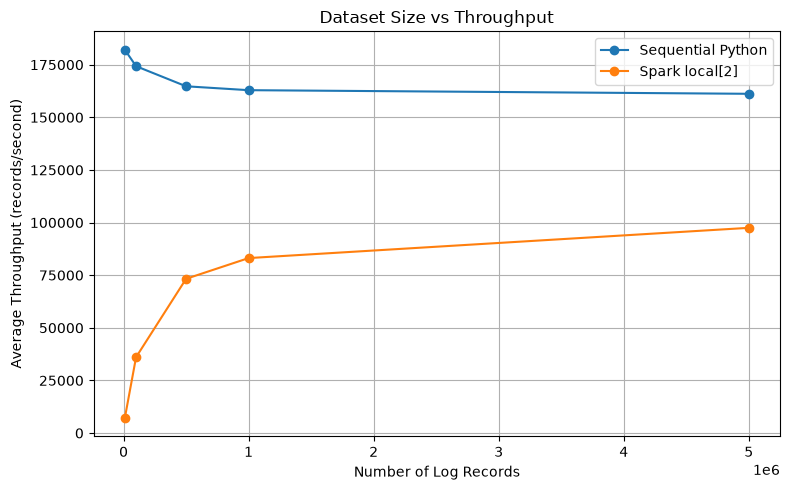

In [59]:
avg_throughput = (
    scaling_df
    .groupby(["Records", "Method"])["Throughput"]
    .mean()
    .reset_index()
)

python_tp = avg_throughput[
    avg_throughput["Method"] == "Sequential Python"
]

spark_tp = avg_throughput[
    avg_throughput["Method"] == "Spark"
]

plt.figure(figsize=(8, 5))

plt.plot(
    python_tp["Records"],
    python_tp["Throughput"],
    marker="o",
    label="Sequential Python"
)

plt.plot(
    spark_tp["Records"],
    spark_tp["Throughput"],
    marker="o",
    label="Spark local[2]"
)

plt.xlabel("Number of Log Records")
plt.ylabel("Average Throughput (records/second)")
plt.title("Dataset Size vs Throughput")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

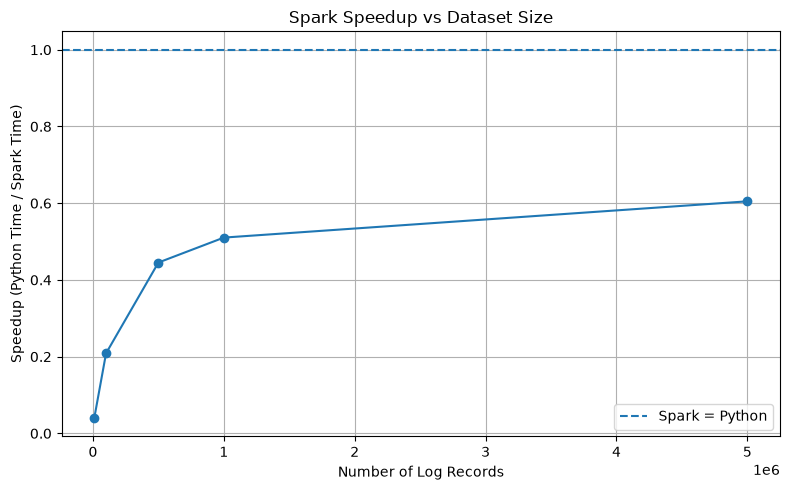

In [60]:
speedup_data = []

for dataset, records, python_results, spark_results in dataset_results:

    python_mean = sum(r[1] for r in python_results) / len(python_results)
    spark_mean = sum(r[1] for r in spark_results) / len(spark_results)

    speedup = python_mean / spark_mean

    speedup_data.append([
        records,
        speedup
    ])

speedup_df = pd.DataFrame(
    speedup_data,
    columns=["Records", "Speedup"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    speedup_df["Records"],
    speedup_df["Speedup"],
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Spark = Python"
)

plt.xlabel("Number of Log Records")
plt.ylabel("Speedup (Python Time / Spark Time)")
plt.title("Spark Speedup vs Dataset Size")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

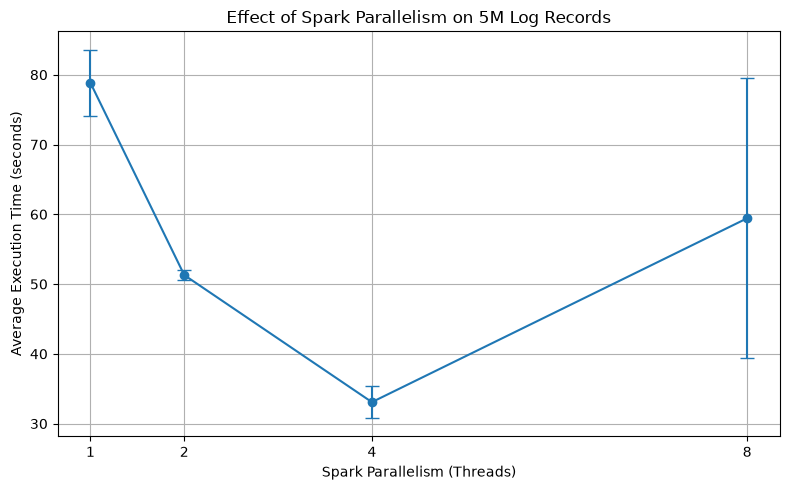

In [61]:
parallel_summary = (
    df_results[
        df_results["Experiment"] == "Parallelism"
    ]
    .groupby("Parallelism")["Execution_Time"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    parallel_summary["Parallelism"],
    parallel_summary["mean"],
    yerr=parallel_summary["std"],
    marker="o",
    capsize=5
)

plt.xlabel("Spark Parallelism (Threads)")
plt.ylabel("Average Execution Time (seconds)")
plt.title("Effect of Spark Parallelism on 5M Log Records")

plt.xticks([1, 2, 4, 8])
plt.grid(True)
plt.tight_layout()

plt.show()

In [62]:
final_scaling_table = (
    scaling_df
    .groupby(["Dataset", "Records", "Method"])
    .agg(
        Mean_Time=("Execution_Time", "mean"),
        Std_Time=("Execution_Time", "std"),
        Mean_Throughput=("Throughput", "mean")
    )
    .reset_index()
)

# Keep datasets in correct size order
final_scaling_table = final_scaling_table.sort_values(
    ["Records", "Method"]
)

print(final_scaling_table.to_string(index=False))

Dataset  Records            Method  Mean_Time  Std_Time  Mean_Throughput
    10K    10000 Sequential Python   0.055973  0.008787    182104.215744
    10K    10000             Spark   1.404579  0.022129      7120.998389
   100K   100000 Sequential Python   0.579748  0.061934    174294.432500
   100K   100000             Spark   2.779090  0.127138     36047.162689
   500K   500000 Sequential Python   3.039661  0.131749    164744.522405
   500K   500000             Spark   6.825981  0.158129     73281.571005
     1M  1000000 Sequential Python   6.140431  0.112781    162898.810560
     1M  1000000             Spark  12.031658  0.200480     83132.598400
     5M  5000000 Sequential Python  31.023196  0.275468    161179.794366
     5M  5000000             Spark  51.290407  0.777013     97501.810264


In [63]:
final_parallelism_table = (
    df_results[
        df_results["Experiment"] == "Parallelism"
    ]
    .groupby("Parallelism")
    .agg(
        Mean_Time=("Execution_Time", "mean"),
        Std_Time=("Execution_Time", "std"),
        Mean_Throughput=("Throughput", "mean")
    )
    .reset_index()
    .sort_values("Parallelism")
)

print(final_parallelism_table.to_string(index=False))

 Parallelism  Mean_Time  Std_Time  Mean_Throughput
           1  78.834277  4.747674     63596.084361
           2  51.290407  0.777013     97501.810264
           4  33.081633  2.286515    151693.910997
           8  59.432234 20.082600     95196.730944
